# Chat GPT

In [1]:
import pandas as pd
from openai import OpenAI
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import argparse
import csv
import os

from _0_prepare_tasks import clean_csv
from _1_translate_tasks import translate_csv
from _2_solve_tasks import solve_tasks
from _3_technical_terms import extract_technical_terms
from _4_evaluate_solution import evaluate_solutions
from _5_cross_lang_validation import compare_results

## Data collection

#### Cleaning exercises list file

In [2]:
input_exercises_en = "math_exercises_en_en.csv"

### Translate exercises to German and Arabic

In [3]:
input_exercises_de = "math_exercises_en_de.csv"
input_exercises_ar = "math_exercises_en_ar.csv"

**German translation**

In [4]:
translate_csv(input_exercises_en, input_exercises_de, target_language="German")
print(f"Translated tasks to German saved to {input_exercises_de}")

Translating exercises from English to German...
Translation to German complete. CSV file saved as: math_exercises_en_de.csv.
Translated tasks to German saved to math_exercises_en_de.csv


**Arabic translation**

In [5]:
translate_csv(input_exercises_en, input_exercises_ar, target_language="Arabic")
print(f"Translated tasks to Arabic saved to {input_exercises_ar}")

Translating exercises from English to Arabic...
Translation to Arabic complete. CSV file saved as: math_exercises_en_ar.csv.
Translated tasks to Arabic saved to math_exercises_en_ar.csv


## Extracting technical terms

In [6]:
terms_en = "technical_terms_en.csv"
terms_de = "technical_terms_de.csv"
terms_ar = "technical_terms_ar.csv"

English terms

In [7]:
extract_technical_terms(input_exercises_en, terms_en, target_language="en")
print(f"Extracted technical terms in English saved to {terms_en}")

Extracting technical terms for task 1: Write the number that comes after 48
Extracting technical terms for task 2: Show 28 using tens and ones
Extracting technical terms for task 3: Circle all even numbers: 12, 15, 18, 21
Extracting technical terms for task 4: What number has 5 tens and 2 ones?
Extracting technical terms for task 5: Fill in the blank: 40, 50, ___, 70
Extracting technical terms for task 6: Write the missing number: ___, 91, 92, 93
Extracting technical terms for task 7: Circle all the numbers that are greater than 25: 14, 26, 30, 19
Extracting technical terms for task 8: Write the number in expanded form: 46 = ___ + ___
Extracting technical terms for task 9: What is the place value of the 6 in 6,524?
Extracting technical terms for task 10: Round 8,649 to the nearest hundred
Extracting technical terms for task 11: How many hundreds are there in 6,400?
Extracting technical terms for task 12: Fill in the blank: 7,000 + 600 + ___ + 5 = 7,685
Extracting technical terms for ta

German terms

In [8]:
extract_technical_terms(input_exercises_de, terms_de, target_language="de")
print(f"Extracted technical terms in German saved to {terms_de}")

Extracting technical terms for task 1: Schreibe die Zahl, die nach 48 kommt.
Extracting technical terms for task 2: Zeige 28 mit Zehnern und Einer.
Extracting technical terms for task 3: Umrahme alle geraden Zahlen: 12, 15, 18, 21.
Extracting technical terms for task 4: Welche Zahl hat 5 Zehner und 2 Einer?
Extracting technical terms for task 5: Vervollständige die Reihe: 40, 50, ___, 70.
Extracting technical terms for task 6: Schreibe die fehlende Zahl: ___, 91, 92, 93
Extracting technical terms for task 7: Umkreise alle Zahlen, die größer als 25 sind: 14, 26, 30, 19.
Extracting technical terms for task 8: Schreibe die Zahl in erweiterter Form: 46 = ___ + ___
Extracting technical terms for task 9: Was ist der Stellenwert der 6 in der Zahl 6.524?
Extracting technical terms for task 10: Runde 8.649 auf die nächste Hunderterstelle.
Extracting technical terms for task 11: Wie viele Hunderter sind in 6.400 enthalten?
Extracting technical terms for task 12: Lücke ausfüllen: 7.000 + 600 + __

Arabic terms

In [9]:
extract_technical_terms(input_exercises_ar, terms_ar, target_language="ar")
print(f"Extracted technical terms in Arabic saved to {terms_ar}")

Extracting technical terms for task 1: اكتب الرقم الذي يأتي بعد ٤٨
Extracting technical terms for task 2: أظهر الرقم 28 باستخدام العشرات والآحاد.
Extracting technical terms for task 3: ضع دائرة حول جميع الأعداد الزوجية: ١٢، ١٥، ١٨، ٢١
Extracting technical terms for task 4: أي عدد يحتوي على 5 عشرات و2 وحدات؟
Extracting technical terms for task 5: أكمل الفراغ: 40، 50، ___، 70
Extracting technical terms for task 6: اكتب الرقم المفقود: ___، ٩١، ٩٢، ٩٣
Extracting technical terms for task 7: ضع دائرة حول جميع الأعداد التي تزيد عن 25: 14، 26، 30، 19
Extracting technical terms for task 8: اكتب العدد ٤٦ بالشكل المفكك: ٤٦ = ___ + ___
Extracting technical terms for task 9: ما قيمة المنزلة للرقم 6 في العدد 6,524؟
Extracting technical terms for task 10: قُم بتقريب العدد 8,649 إلى أقرب مئة.
Extracting technical terms for task 11: كم عدد المئات في 6400؟
Extracting technical terms for task 12: كمال الفراغ: ٧٠٠٠ + ٦٠٠ + ___ + ٥ = ٧٦٨٥
Extracting technical terms for task 13: اكتب أصغر عدد مكون من 4 أرقا

## Solving Exercises

In [10]:
solved_exercises_en = "solutions_en.csv"
solved_exercises_de = "solutions_de.csv"
solved_exercises_ar = "solutions_ar.csv"

In [11]:
def show_results_overview(df, model="gpt-4o-mini"):
    for index, row in df.iterrows():
        if index > 3:
            break;
        print(f"Topic Area: {row['Topic Area']}")
        print(f"Topic: {row['Topic']}")
        print(f"Progress Level: {row['Progress Level']}")
        print(f"Exercise: {row['Exercise']}")
        print()
        print(f"gpt-4o solution:")
        print(f"{row[f"{model} solution"]}")
        print(f"--------------------------\n")

In [12]:
import importlib
import _2_solve_tasks

importlib.reload(_2_solve_tasks)
from _2_solve_tasks import solve_tasks

**English Solutions:**

In [13]:
solve_tasks(input_exercises_en, solved_exercises_en)
print(f"Solved tasks in English saved to {solved_exercises_en}")

df_en = pd.read_csv(solved_exercises_en)
print(df_en.head())

Solving task 1: Write the number that comes after 48
Solving task 2: Show 28 using tens and ones
Solving task 3: Circle all even numbers: 12, 15, 18, 21
Solving task 4: What number has 5 tens and 2 ones?
Solving task 5: Fill in the blank: 40, 50, ___, 70
Solving task 6: Write the missing number: ___, 91, 92, 93
Solving task 7: Circle all the numbers that are greater than 25: 14, 26, 30, 19
Solving task 8: Write the number in expanded form: 46 = ___ + ___
Solving task 9: What is the place value of the 6 in 6,524?
Solving task 10: Round 8,649 to the nearest hundred
Solving task 11: How many hundreds are there in 6,400?
Solving task 12: Fill in the blank: 7,000 + 600 + ___ + 5 = 7,685
Solving task 13: Write the smallest 4-digit number you can make using 4, 1, 8, 0.
Solving task 14: Show the fraction (½) with a fraction bar
Solving task 15: Write 234 in expanded form
Solving task 16: Express 3.75 as a fraction
Solving task 17: Compare using <, >, or =: 3.25 ___ 3.205
Solving task 18: Conve

**German Solutions:**

In [14]:
solve_tasks(input_exercises_de, solved_exercises_de, prompt_prefix='Erkläre mir wie ich diese Matheaufgabe lösen kann')
print(f"Solved tasks in German saved to {solved_exercises_de}")

Solving task 1: Schreibe die Zahl, die nach 48 kommt.
Solving task 2: Zeige 28 mit Zehnern und Einer.
Solving task 3: Umrahme alle geraden Zahlen: 12, 15, 18, 21.
Solving task 4: Welche Zahl hat 5 Zehner und 2 Einer?
Solving task 5: Vervollständige die Reihe: 40, 50, ___, 70.
Solving task 6: Schreibe die fehlende Zahl: ___, 91, 92, 93
Solving task 7: Umkreise alle Zahlen, die größer als 25 sind: 14, 26, 30, 19.
Solving task 8: Schreibe die Zahl in erweiterter Form: 46 = ___ + ___
Solving task 9: Was ist der Stellenwert der 6 in der Zahl 6.524?
Solving task 10: Runde 8.649 auf die nächste Hunderterstelle.
Solving task 11: Wie viele Hunderter sind in 6.400 enthalten?
Solving task 12: Lücke ausfüllen: 7.000 + 600 + ___ + 5 = 7.685
Solving task 13: Schreibe die kleinste 4-stellige Zahl, die du mit den Ziffern 4, 1, 8 und 0 bilden kannst.
Solving task 14: Zeige den Bruch (½) mit einer Bruchleiste.
Solving task 15: Schreibe 234 in erweiterter Form.
Solving task 16: Drücke 3,75 als Bruch aus.

**Arabic Solutions:**

In [15]:
solve_tasks(input_exercises_ar, solved_exercises_ar, prompt_prefix='اشرح لي كيف يمكنني حل هذه المسألة الرياضية')
print(f"Solved tasks in Arabic saved to {solved_exercises_ar}")

Solving task 1: اكتب الرقم الذي يأتي بعد ٤٨
Solving task 2: أظهر الرقم 28 باستخدام العشرات والآحاد.
Solving task 3: ضع دائرة حول جميع الأعداد الزوجية: ١٢، ١٥، ١٨، ٢١
Solving task 4: أي عدد يحتوي على 5 عشرات و2 وحدات؟
Solving task 5: أكمل الفراغ: 40، 50، ___، 70
Solving task 6: اكتب الرقم المفقود: ___، ٩١، ٩٢، ٩٣
Solving task 7: ضع دائرة حول جميع الأعداد التي تزيد عن 25: 14، 26، 30، 19
Solving task 8: اكتب العدد ٤٦ بالشكل المفكك: ٤٦ = ___ + ___
Solving task 9: ما قيمة المنزلة للرقم 6 في العدد 6,524؟
Solving task 10: قُم بتقريب العدد 8,649 إلى أقرب مئة.
Solving task 11: كم عدد المئات في 6400؟
Solving task 12: كمال الفراغ: ٧٠٠٠ + ٦٠٠ + ___ + ٥ = ٧٦٨٥
Solving task 13: اكتب أصغر عدد مكون من 4 أرقام يمكنك تشكيله باستخدام الأرقام 4، 1، 8، 0.
Solving task 14: أظهر الكسر (½) باستخدام شريط الكسور.
Solving task 15: اكتب 234 بالشكل الموسع.
Solving task 16: عبّر عن 3.75 على صورة كسر اعتيادي.
Solving task 17: قارن باستخدام <، >، أو =: 3.25 ___ 3.205
Solving task 18: حوّل العدد ٢٧ من النظام العشري (ا

## Pairwise Evaluation

In [14]:
solution_files = {
    "en": solved_exercises_en,
    "de": solved_exercises_de,
    "ar": solved_exercises_ar,
}

technical_terms_files = {
    "en": "technical_terms_en.csv",
    "de": "technical_terms_de.csv",
    "ar": "technical_terms_ar.csv",
}

In [15]:
import importlib
import _7_pairwise_evaluation

importlib.reload(_7_pairwise_evaluation)
from _7_pairwise_evaluation import evaluate_explanations

C:\Users\IuG_Lap1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
df_results = evaluate_explanations(solution_files, technical_terms_files, current_model="gpt-4o-mini")

pd.set_option('display.max_colwidth', None)  # Ensure long explanations are visible
print(df_results.head())

Evaluating exercise 0... ✅ Saved exercise 0 to CSV.
Evaluating exercise 1... ✅ Saved exercise 1 to CSV.
Evaluating exercise 2... ✅ Saved exercise 2 to CSV.
Evaluating exercise 3... ✅ Saved exercise 3 to CSV.
Evaluating exercise 4... ✅ Saved exercise 4 to CSV.
Evaluating exercise 5... ✅ Saved exercise 5 to CSV.
Evaluating exercise 6... ✅ Saved exercise 6 to CSV.
Evaluating exercise 7... ✅ Saved exercise 7 to CSV.
Evaluating exercise 8... ✅ Saved exercise 8 to CSV.
Evaluating exercise 9... ✅ Saved exercise 9 to CSV.
Evaluating exercise 10... ✅ Saved exercise 10 to CSV.
Evaluating exercise 11... ✅ Saved exercise 11 to CSV.
Evaluating exercise 12... ✅ Saved exercise 12 to CSV.
Evaluating exercise 13... ✅ Saved exercise 13 to CSV.
Evaluating exercise 14... ✅ Saved exercise 14 to CSV.
Evaluating exercise 15... ✅ Saved exercise 15 to CSV.
Evaluating exercise 16... ✅ Saved exercise 16 to CSV.
Evaluating exercise 17... ✅ Saved exercise 17 to CSV.
Evaluating exercise 18... ✅ Saved exercise 18 to

In [16]:
# re-evaluate skipped exercises
evaluate_explanations(solution_files, technical_terms_files, current_model="gpt-4o-mini",
                     tasks_indices=[28, 74, 111, 154, 308, 461]);

Evaluating exercise 28... ✅ Saved exercise 28 to CSV.
Evaluating exercise 74... ✅ Saved exercise 74 to CSV.
Evaluating exercise 111... ✅ Saved exercise 111 to CSV.
Evaluating exercise 154... ✅ Saved exercise 154 to CSV.
Evaluating exercise 308... ✅ Saved exercise 308 to CSV.
Evaluating exercise 461... ✅ Saved exercise 461 to CSV.
Ranking-based evaluation completed. Results saved to judge_pairwise_evaluation.csv


In [28]:
import importlib
import _8_pairwise_results_clean

importlib.reload(_8_pairwise_results_clean)
from _8_pairwise_results_clean import pairwise_results_clean

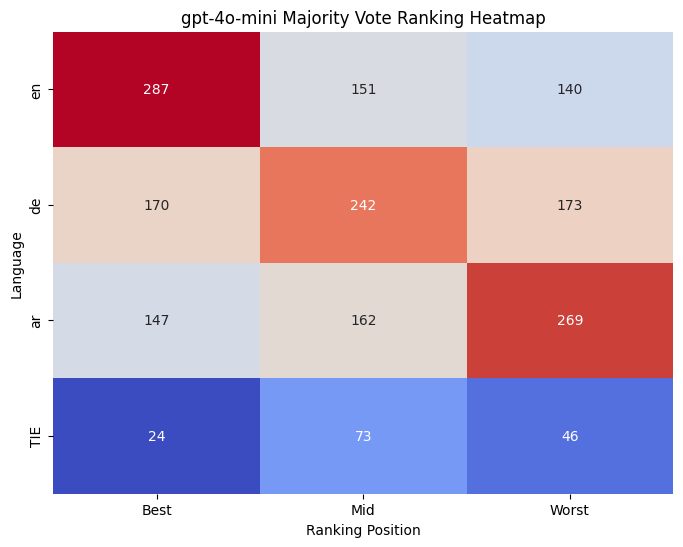

In [29]:
pairwise_results_clean(solving_model="gpt-4o-mini")

Skipping gpt-4o-mini: no valid rankings found.


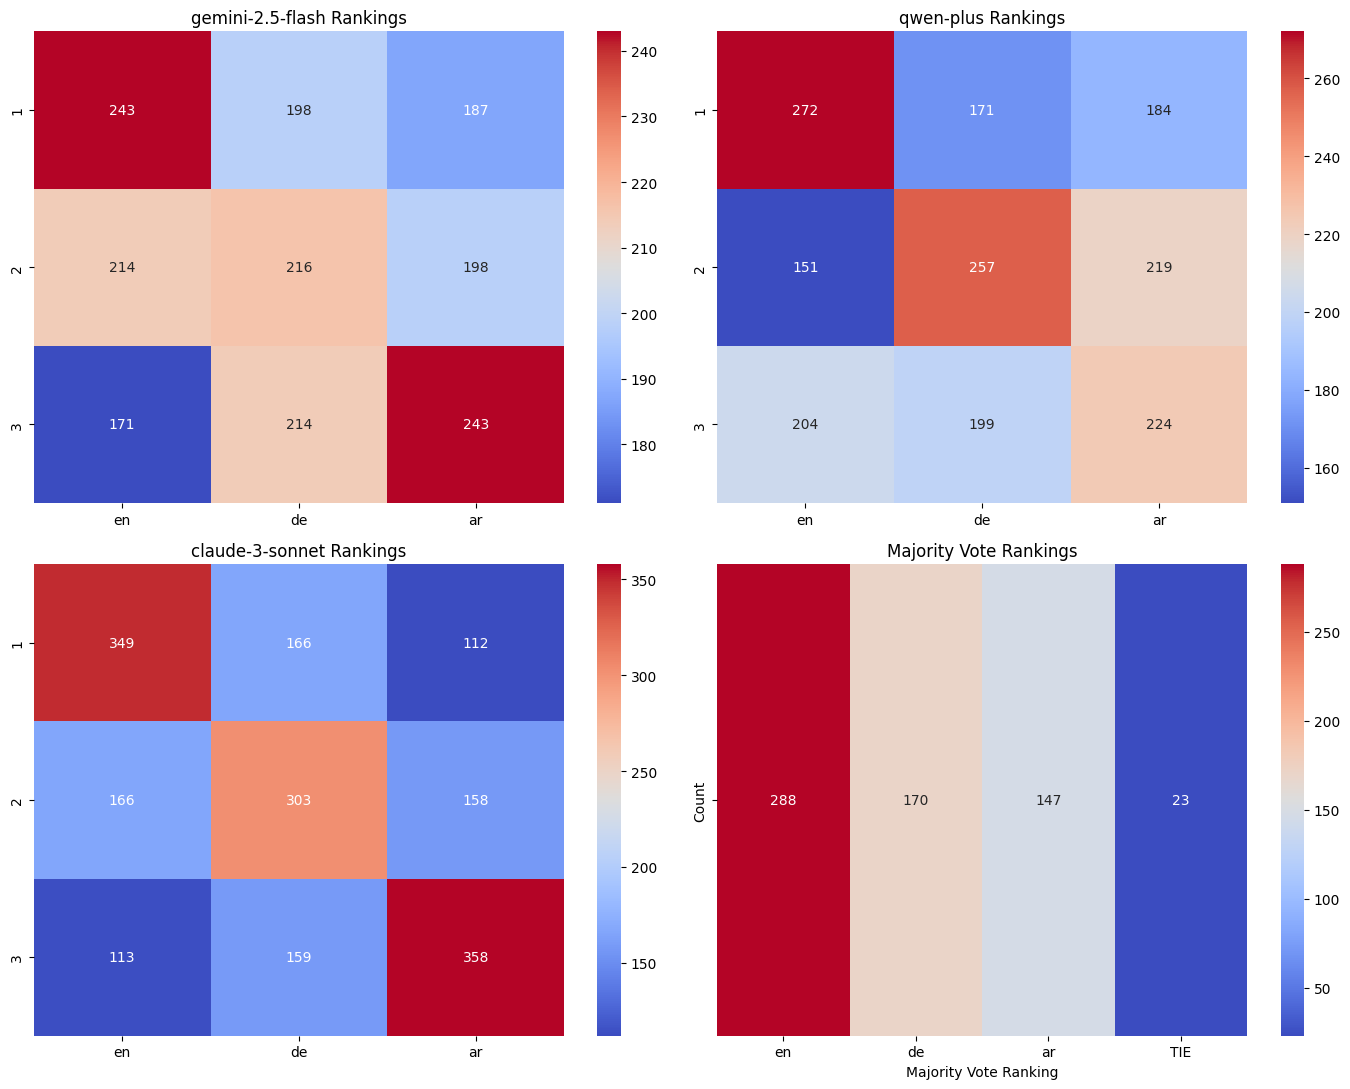

In [30]:
import ast
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

expected_languages = list(solution_files.keys())  # e.g. ['en', 'de', 'ar']

def parse_ranking(ranking_str):
    """Converts a ranking string like '[en: 1, de: 2, ar: 3]' into a dictionary."""
    try:
        if not isinstance(ranking_str, str):
            return {}
        formatted_str = ranking_str.replace("Lang1", "en").replace("Lang2", "de").replace("Lang3", "ar")
        ranking_dict = eval(formatted_str)
        return ranking_dict if isinstance(ranking_dict, dict) else {}
    except Exception as e:
        print(f"Error parsing ranking: {ranking_str} -> {e}")
        return {}

# Load the evaluation results
df_results = pd.read_csv('judge_pairwise_evaluation.csv')

# List of model columns to process
model_cols = [col for col in df_results.columns if "Ranking" in col and "Majority" not in col]

# Parse all model rankings
for col in model_cols:
    df_results[col] = df_results[col].apply(parse_ranking)

# Convert to ranking DataFrames and store results
ranking_dataframes = {}
ranking_counts = {}

for model_col in model_cols:
    model_name = model_col.replace(" Ranking", "")

    # Convert column of dicts to DataFrame only if non-empty
    all_rankings = df_results[model_col].to_list()
    valid_rankings = [r for r in all_rankings if isinstance(r, dict) and len(r) == len(expected_languages)]

    if not valid_rankings:
        print(f"Skipping {model_name}: no valid rankings found.")
        continue

    model_df = pd.DataFrame(valid_rankings)

    # Handle unexpected column mismatches
    if model_df.shape[1] != len(expected_languages):
        print(f"Warning: {model_name} has {model_df.shape[1]} columns instead of {len(expected_languages)}.")
        continue

    model_df.columns = expected_languages
    ranking_dataframes[model_name] = model_df
    ranking_counts[model_name] = model_df.apply(pd.Series.value_counts).fillna(0).astype(int)

# Handle majority vote counts
majority_ranking_counts = df_results["Majority Vote Ranking"].value_counts().to_frame()
majority_ranking_counts.columns = ["Count"]

# Plotting
num_models = len(ranking_counts)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes = axes.flatten()

# Plot each judge model
for idx, (model_name, counts) in enumerate(ranking_counts.items()):
    sns.heatmap(counts, annot=True, cmap="coolwarm", fmt="d", ax=axes[idx])
    axes[idx].set_title(f"{model_name} Rankings")

# Plot majority vote
sns.heatmap(majority_ranking_counts.T, annot=True, cmap="coolwarm", fmt="d", ax=axes[-1])
axes[-1].set_title("Majority Vote Rankings")

# Clean layout
plt.tight_layout()
plt.show()

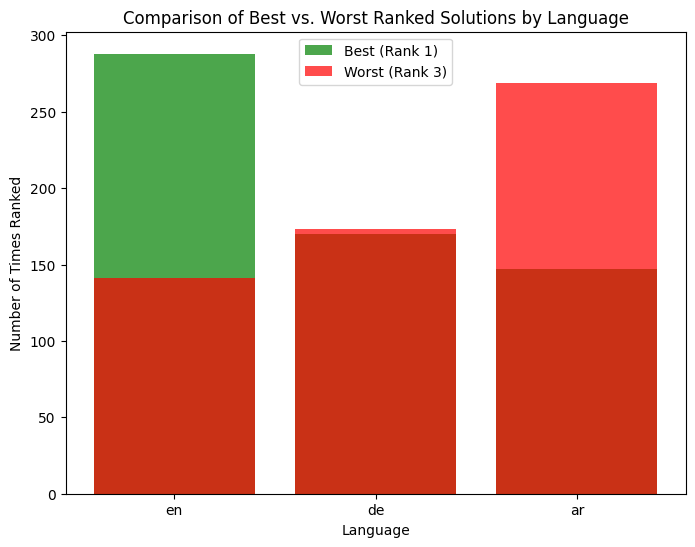

In [31]:
import matplotlib.pyplot as plt

# Count occurrences of each language in best and worst rankings
best_counts = df_results["Best Explanation"].value_counts()
worst_counts = df_results["Worst Explanation"].value_counts()

# Ensure all languages are included (even if they have 0 counts)
languages = list(solution_files.keys())  # ['en', 'de', 'ar']
best_counts = best_counts.reindex(languages, fill_value=0)
worst_counts = worst_counts.reindex(languages, fill_value=0)

# Plot bar chart
plt.figure(figsize=(8, 6))
plt.bar(best_counts.index, best_counts.values, label="Best (Rank 1)", color="green", alpha=0.7)
plt.bar(worst_counts.index, worst_counts.values, label="Worst (Rank 3)", color="red", alpha=0.7)
plt.xlabel("Language")
plt.ylabel("Number of Times Ranked")
plt.title("Comparison of Best vs. Worst Ranked Solutions by Language")
plt.legend()
plt.show()

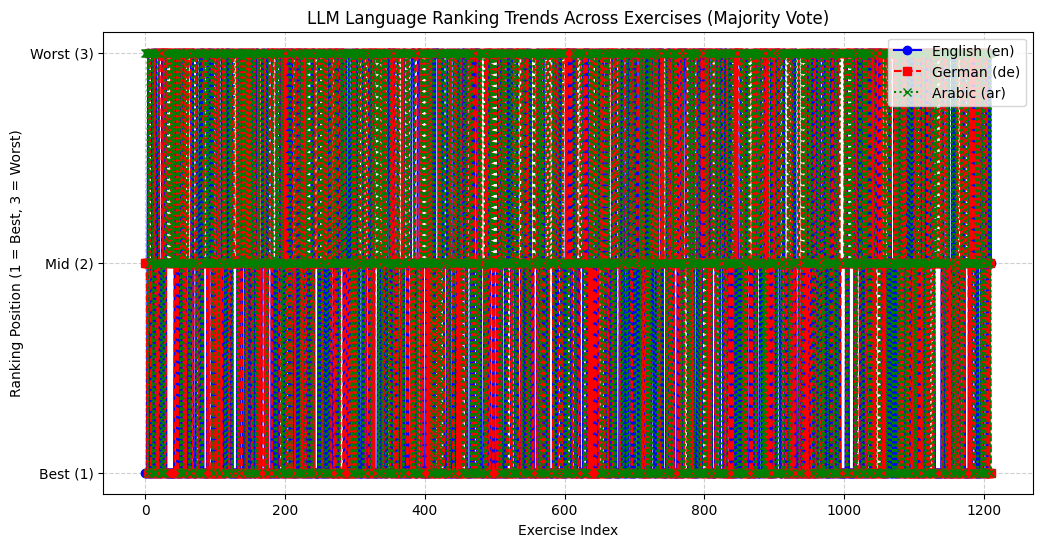

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Define models and languages
models = ["gpt-4o-mini", "gemini-1.5-flash", "qwen-plus"]
languages = ["en", "de", "ar"]  # Fixed order for consistency

# Create lists for each language's ranking position across exercises
en_ranking, de_ranking, ar_ranking = [], [], []

# Iterate through all exercises
for _, row in df_results.iterrows():
    majority_best = row["Majority Vote Ranking"]  # The best language from Majority Vote
    if not isinstance(majority_best, str) or majority_best not in languages:
        continue  # Skip if invalid

    # Get the remaining two languages
    remaining_languages = [lang for lang in languages if lang != majority_best]
    if len(remaining_languages) != 2:
        continue  # Skip if incomplete data

    # Collect worst ranking votes across models
    worst_votes = Counter()
    for model in models:
        ranking_value = row.get(f"{model} Ranking", "")

        # Ensure ranking_value is a dictionary (convert string if needed)
        if isinstance(ranking_value, str) and ranking_value.strip().startswith("{"):
            try:
                ranking_dict = eval(ranking_value)  # Convert string to dictionary
            except:
                continue
        elif isinstance(ranking_value, dict):
            ranking_dict = ranking_value
        else:
            continue  # Skip if the value is neither dict nor valid string

        # Ensure ranking_dict contains all three languages
        if len(ranking_dict) < 3:
            continue  # Skip if incomplete ranking

        # Sort by ranking position (1 = best, 3 = worst)
        sorted_langs = sorted(ranking_dict, key=ranking_dict.get)

        if sorted_langs:
            worst_votes[sorted_langs[-1]] += 1  # Worst gets more votes

    # Determine worst language via majority vote
    worst_language = worst_votes.most_common(1)[0][0] if worst_votes else remaining_languages[0]

    # The last remaining language is the mid-ranked one
    mid_language = [lang for lang in remaining_languages if lang != worst_language][0]

    # Assign rankings to fixed language positions
    rank_mapping = {majority_best: 1, mid_language: 2, worst_language: 3}

    # **Find missing language and its missing rank**
    assigned_ranks = set(rank_mapping.values())  # Ranks that are already used
    missing_rank = list({1, 2, 3} - assigned_ranks)  # Find the missing rank
    missing_lang = list(set(languages) - set(rank_mapping.keys()))  # Find missing language

    # If there's a missing rank and a missing language, assign it
    if missing_lang and missing_rank:
        rank_mapping[missing_lang[0]] = missing_rank[0]

    # Append to ranking lists
    en_ranking.append(rank_mapping["en"])
    de_ranking.append(rank_mapping["de"])
    ar_ranking.append(rank_mapping["ar"])

# Plot the ranking trends with fixed colors
plt.figure(figsize=(12, 6))

plt.plot(range(len(en_ranking)), en_ranking, marker="o", linestyle="-", label="English (en)", color="blue")
plt.plot(range(len(de_ranking)), de_ranking, marker="s", linestyle="--", label="German (de)", color="red")
plt.plot(range(len(ar_ranking)), ar_ranking, marker="x", linestyle=":", label="Arabic (ar)", color="green")

plt.xlabel("Exercise Index")
plt.ylabel("Ranking Position (1 = Best, 3 = Worst)")
plt.title("LLM Language Ranking Trends Across Exercises (Majority Vote)")
plt.yticks([1, 2, 3], labels=["Best (1)", "Mid (2)", "Worst (3)"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

---

### ===> (Deprecated)

The next section contains the results of direct evaluation scoring.

The results from the following sections are from an old trial and were not included in the paper. This technique was replaced by pairwise evaluation as it provided better and more objective insights into model's profeciency accross languages.

## Evaluating Solutions

In [17]:
evaluations_en = "topic_areas_evaluations_en.csv"
evaluations_de = "topic_areas_evaluations_de.csv"
evaluations_ar = "topic_areas_evaluations_ar.csv"

In [64]:
import importlib
import _4_evaluate_solution

importlib.reload(_4_evaluate_solution)
from _4_evaluate_solution import evaluate_solutions

In [65]:
evaluate_solutions(solved_exercises_en, terms_en, evaluations_en)
print(f"Evaluation of solutions in English saved to {evaluations_en}")

Evaluating solution for task 1: Draw 10 stars in the box and color 5 of them blue.
Evaluating solution for task 2: Count the number of apples in the picture and write the total number in the empty circle below.
Evaluating solution for task 3: Write the numbers from 1 to 20 in order on the lines provided.
Evaluating solution for task 4: Draw lines to connect the numbers 1 to 20 with their matching dot patterns.
Evaluating solution for task 5: Circle the number that has the same number of dots underneath it; for example if you see 5 dots circle the number 5.
Evaluating solution for task 6: Fill in the blanks with the correct number symbol that matches the dot patterns shown on the page.
Evaluating solution for task 7: Emma has 24 apples and she gives 13 apples to her friend; how many apples does she have left?
Evaluating solution for task 8: A farmer has 36 carrots and picks another 12 carrots; how many carrots does he have in total?
Evaluating solution for task 9: Liam read 45 pages of 

In [66]:
evaluate_solutions(solved_exercises_de, terms_de, evaluations_de)
print(f"Evaluation of solutions in German saved to {evaluations_de}")

Evaluating solution for task 1: Zeichne 10 Sterne in das Kästchen und male 5 davon blau.
Evaluating solution for task 2: Zähle die Anzahl der Äpfel im Bild und schreibe die Gesamtsumme in den leeren Kreis darunter.
Evaluating solution for task 3: Schreibe die Zahlen von 1 bis 20 der Reihenfolge nach auf die vorgesehenen Linien.
Evaluating solution for task 4: Zeichne Linien, um die Zahlen 1 bis 20 mit ihren passenden Punktmustern zu verbinden.
Evaluating solution for task 5: Umkreise die Zahl, die die gleiche Anzahl von Punkten darunter hat; zum Beispiel, wenn du 5 Punkte siehst, umkreise die Zahl 5.
Evaluating solution for task 6: Fülle die Lücken mit dem richtigen Zahlensymbol aus, das den auf der Seite gezeigten Punktmustern entspricht.
Evaluating solution for task 7: Emma hat 24 Äpfel und sie gibt 13 Äpfel an ihre Freundin; wie viele Äpfel hat sie noch?
Evaluating solution for task 8: Ein Bauer hat 36 Karotten und pflückt weitere 12 Karotten; wie viele Karotten hat er insgesamt?
Ev

In [67]:
evaluate_solutions(solved_exercises_ar, terms_ar, evaluations_ar)
print(f"Evaluation of solutions in Arabic saved to {evaluations_ar}")

Evaluating solution for task 1: ارسم 10 نجوم في الصندوق والون 5 منها باللون الأزرق.
Evaluating solution for task 2: احسب عدد التفاح في الصورة واكتب العدد الكلي في الدائرة الفارغة أدناه.
Evaluating solution for task 3: اكتب الأرقام من 1 إلى 20 بالترتيب على الأسطر المتاحة.
Evaluating solution for task 4: ارسم خطوطاً لربط الأرقام من 1 إلى 20 بأنماط النقاط المطابقة لها.
Evaluating solution for task 5: قم بدائرة الرقم الذي يحتوي على نفس عدد النقاط الموجودة تحته؛ على سبيل المثال، إذا رأيت 5 نقاط، قم بدائرة الرقم 5.
Evaluating solution for task 6: املأ الفراغات بالرمز الرقمي الصحيح الذي يطابق أنماط النقاط الموضحة في الصفحة.
Evaluating solution for task 7: إيما لديها 24 تفاحة وقد أعطت 13 تفاحة لصديقتها؛ كم عدد التفاح المتبقي لديها؟
Evaluating solution for task 8: مزارع لديه 36 جزرة ويقطف 12 جزرة أخرى؛ كم عدد الجزر التي يمتلكها في المجموع؟
Evaluating solution for task 9: ليام قرأ 45 صفحة من كتابه ثم أنهى 22 صفحة أخرى؛ فكم صفحًة قرأها إجمالًا؟
Evaluating solution for task 10: سارة لديها 8 علب من

## Results Comparisons

In [68]:
files = {
    "en": evaluations_en,
    "de": evaluations_de,
    "ar": evaluations_ar,
}

In [69]:
import importlib
import _5_cross_lang_validation

importlib.reload(_5_cross_lang_validation)
from _5_cross_lang_validation import compare_results

In [70]:
cross_validation_results = compare_results(files)

Index(['Topic Area', 'Topic', 'Progress Level', 'Exercise',
       'Problem Understanding (Comprehension)',
       'Clarity and Step-by-Step Explanation',
       'Accuracy of Process (Correctness of Steps)',
       'Correctness of Final Answer', 'Learning Appropriateness',
       'Generalization', 'Technical Terms Explanation',
       'Addressing Common Errors', 'Appropriateness Based on Progress Level',
       'Explanation Clarity & Syntax', 'Justification'],
      dtype='object')
Index(['Topic Area', 'Topic', 'Progress Level', 'Exercise',
       'Problem Understanding (Comprehension)',
       'Clarity and Step-by-Step Explanation',
       'Accuracy of Process (Correctness of Steps)',
       'Correctness of Final Answer', 'Learning Appropriateness',
       'Generalization', 'Technical Terms Explanation',
       'Addressing Common Errors', 'Appropriateness Based on Progress Level',
       'Explanation Clarity & Syntax', 'Justification'],
      dtype='object')
Index(['Topic Area', 'Topi

In [71]:
comparison_results = pd.read_csv('comparison_results.csv')
highest_averages = pd.read_csv('highest_averages.csv')

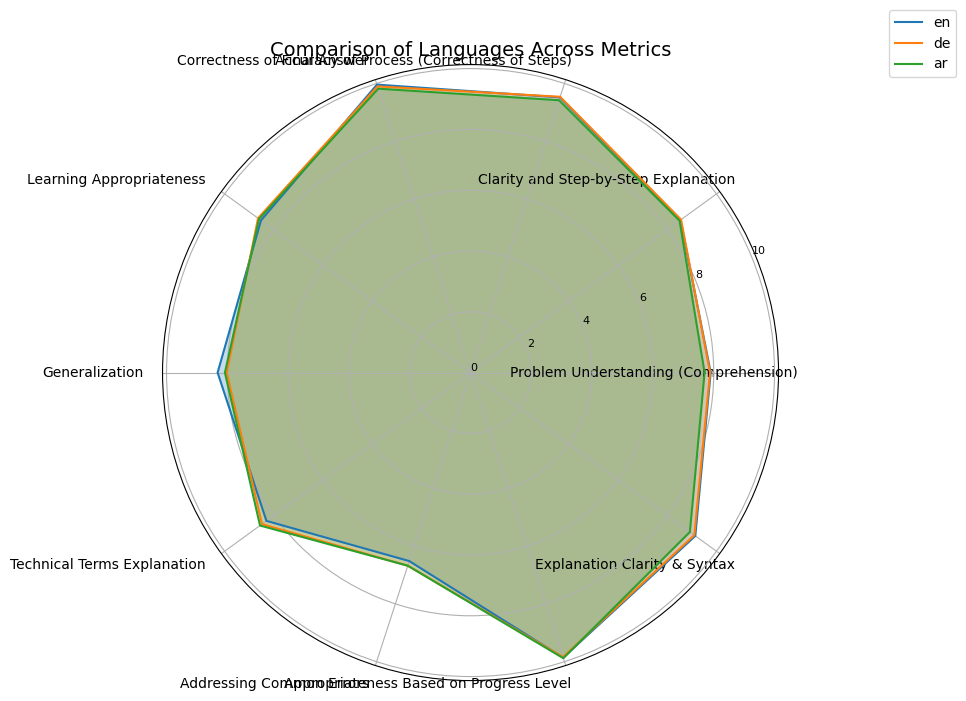

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read data from CSV
file_path = "comparison_results.csv"
df = pd.read_csv(file_path, index_col=0)  # Load CSV, set first column as index (languages)

# Extract languages and metrics dynamically
languages = df.index.tolist()
metrics = df.columns.tolist()

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each language's data
for lang in languages:
    data = df.loc[lang].tolist()  # Extract values for the language
    data += data[:1]  # Close the circle
    ax.plot(angles, data, label=lang)
    ax.fill(angles, data, alpha=0.25)

# Format radar chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10, rotation=30, ha="right")
ax.set_yticks([0, 2, 4, 6, 8, 10])
ax.set_yticklabels(['0', '2', '4', '6', '8', '10'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Comparison of Languages Across Metrics', fontsize=14)
plt.show()


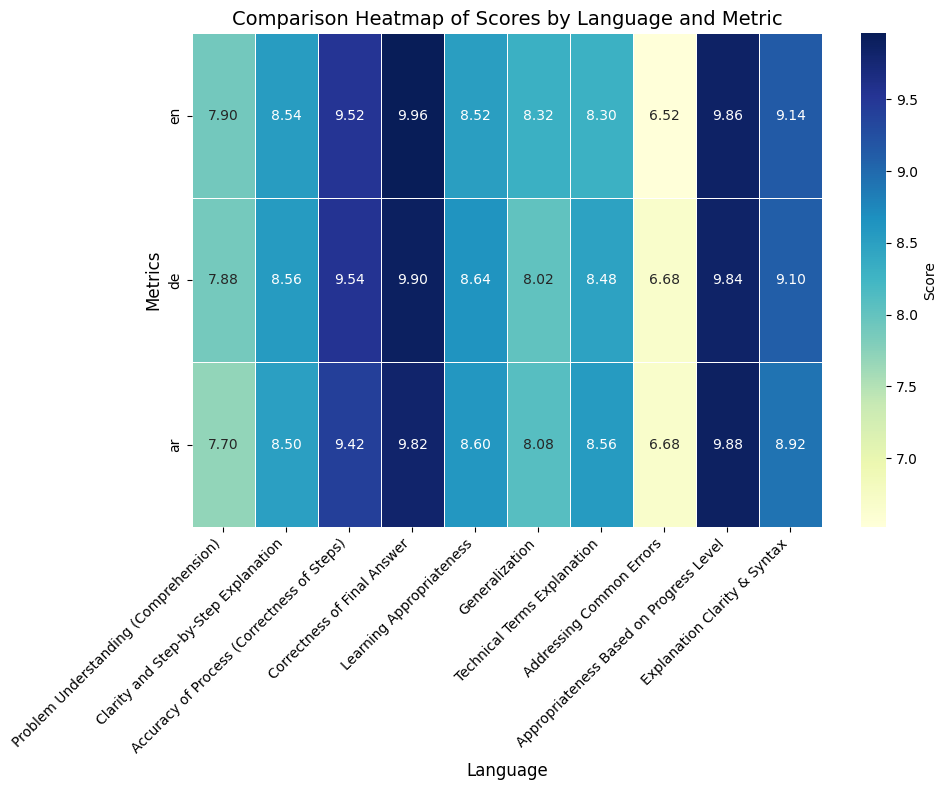

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data from the CSV file
data = pd.read_csv("comparison_results.csv")

# Set the index of the DataFrame to the metrics column
data.set_index("Unnamed: 0", inplace=True)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    data,
    annot=True,  # Show the values in each cell
    cmap="YlGnBu",  # Color palette
    fmt=".2f",  # Format the numbers to 2 decimal places
    linewidths=0.5,  # Add space between cells
    cbar_kws={'label': 'Score'}  # Label for the color bar
)

# Add labels and title
plt.title("Comparison Heatmap of Scores by Language and Metric", fontsize=14)
plt.xlabel("Language", fontsize=12)
plt.ylabel("Metrics", fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

In [75]:
import importlib
import _6_find_differently_performing_exercises

importlib.reload(_6_find_differently_performing_exercises)
from _6_find_differently_performing_exercises import find_differently_performing_exercises

result = find_differently_performing_exercises([evaluations_en, evaluations_de, evaluations_ar])

result.to_csv("most_different_exercises.csv", index=False)

In [76]:
pd.read_csv("most_different_exercises.csv").head()

,exercise,language_1,language_2,language_3,Total_Difference
0,exercise_6,9.2,8.3,6.9,2.3
1,exercise_33,8.1,8.1,6.3,1.8
2,exercise_29,8.9,8.8,7.6,1.3
3,exercise_48,8.4,7.4,8.7,1.3
4,exercise_28,8.7,8.2,9.3,1.1


In [77]:
def get_exercise_solution(index, solutions_en, solutions_de, solutions_ar, model='gpt-4o-mini'):
    # Ensure index is within the bounds of the dataframes
    if index < 0 or index > len(solutions_en):
        raise ValueError("Index is out of bounds for the solutions dataframes.")
    
    # Retrieve the exercise solutions from each language file at the given index
    solution_en = solutions_en.iloc[index-1][f'{model} solution']  # Retrieve exercise solution in English
    solution_de = solutions_de.iloc[index-1][f'{model} solution']  # Retrieve exercise solution in German
    solution_ar = solutions_ar.iloc[index-1][f'{model} solution']  # Retrieve exercise solution in Arabic
    
    # Returning the exercise solutions as a dictionary
    return {
        'Exercise': solutions_en.iloc[index-1]['Exercise'],
        'English': solution_en,
        'German': solution_de,
        'Arabic': solution_ar
    }

In [78]:

# Example of usage:
index = 33  # Example index
sols_en = pd.read_csv(solved_exercises_en)
sols_de = pd.read_csv(solved_exercises_de)
sols_ar = pd.read_csv(solved_exercises_ar)
solutions = get_exercise_solution(index, sols_en, sols_de, sols_ar)
print(solutions['Exercise'])
print('---')
print(solutions['English'])
print('---')
print(solutions['German'])
print('---')
print(solutions['Arabic'])

A baker uses a pattern of ingredients: 1 cup of sugar 2 cups of flour 3 eggs __ __; identify the next two items in this ingredient pattern.
---
To solve the task of identifying the next two items in the ingredient pattern, you can analyze the given sequence of ingredients:

1. **Cup of Sugar**: 1 cup
2. **Cups of Flour**: 2 cups
3. **Eggs**: 3 eggs

From the items listed, it appears that the quantities of the ingredients are increasing incrementally by one for each item:

- The first ingredient (sugar) has 1 cup.
- The second ingredient (flour) has 2 cups.
- The third ingredient (eggs) has 3 eggs.

Assuming this incremental pattern continues, the next ingredient should have 4 of something, followed by 5 of something. 

Next, we need to think about what common baking ingredients might fit this pattern. Common ingredients could be:

4. **Cups of Milk**: 4 cups 
5. **Tablespoons of Butter**: 5 tablespoons (or perhaps 5 cups of something like water)

Therefore, the next two items in the in